In [2]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
#Dataset1-Sine Wave
def sample_sine(n_samples=1000):
    x = np.random.uniform(-np.pi, np.pi, n_samples)
    y = np.sin(x)
    data = np.stack([x, y], axis=1)
    return torch.tensor(data, dtype=torch.float32)

In [3]:
#dataset2 - Mixture of Gaussians
def sample_gaussians(n_samples=1000):
    centers = [(-2, -2), (2, 2), (-2, 2), (2, -2)]
    data = []

    for _ in range(n_samples):
        cx, cy = centers[np.random.randint(0, len(centers))]
        point = np.random.normal(loc=[cx, cy], scale=0.3)
        data.append(point)

    return torch.tensor(data, dtype=torch.float32)

In [4]:

import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, z):
        return self.net(z)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def train_gan(generator, discriminator, data_fn, epochs=2000):
    g_opt = torch.optim.Adam(generator.parameters(), lr=0.001)
    d_opt = torch.optim.Adam(discriminator.parameters(), lr=0.001)
    loss_fn = nn.BCELoss()

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        real_data = data_fn(64)

        real_labels = torch.ones((64, 1))
        fake_labels = torch.zeros((64, 1))

        # Train Discriminator
        z = torch.randn(64, 2)
        fake_data = generator(z).detach()

        d_loss = loss_fn(discriminator(real_data), real_labels) + \
                 loss_fn(discriminator(fake_data), fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Train Generator
        z = torch.randn(64, 2)
        fake_data = generator(z)

        g_loss = loss_fn(discriminator(fake_data), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

    return g_losses, d_losses

In [7]:
def plot_data(generator, data_fn, title):
    torch.manual_seed(42)

    real = data_fn(500).numpy()
    z = torch.randn(500, 2)
    fake = generator(z).detach().numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(real[:,0], real[:,1], label="Real", alpha=0.6)
    plt.scatter(fake[:,0], fake[:,1], label="Fake", alpha=0.6)
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

In [8]:
class GeneratorImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),

            nn.Linear(16, 2)
        )

    def forward(self, z):
        return self.net(z)

In [9]:


class DiscriminatorImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [10]:
def compare_models(gen_before, gen_after, data_fn):
    real = data_fn(500).numpy()

    z = torch.randn(500, 2)
    fake_before = gen_before(z).detach().numpy()

    z = torch.randn(500, 2)
    fake_after = gen_after(z).detach().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    ax[0].scatter(real[:,0], real[:,1], alpha=0.5)
    ax[0].scatter(fake_before[:,0], fake_before[:,1], alpha=0.5)
    ax[0].set_title("Before GAN")

    ax[1].scatter(real[:,0], real[:,1], alpha=0.5)
    ax[1].scatter(fake_after[:,0], fake_after[:,1], alpha=0.5)
    ax[1].set_title("After GAN")

    plt.show()

In [11]:
gen_before = Generator()
disc_before = Discriminator()

g_loss_b, d_loss_b = train_gan(gen_before, disc_before, sample_sine)

gen_after = GeneratorImproved()
disc_after = DiscriminatorImproved()

g_loss_a, d_loss_a = train_gan(gen_after, disc_after, sample_sine)

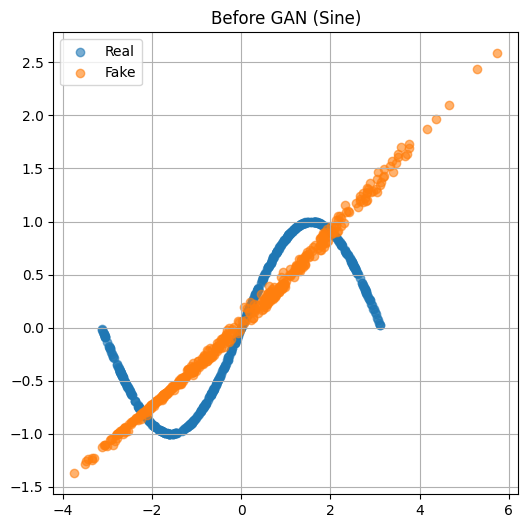

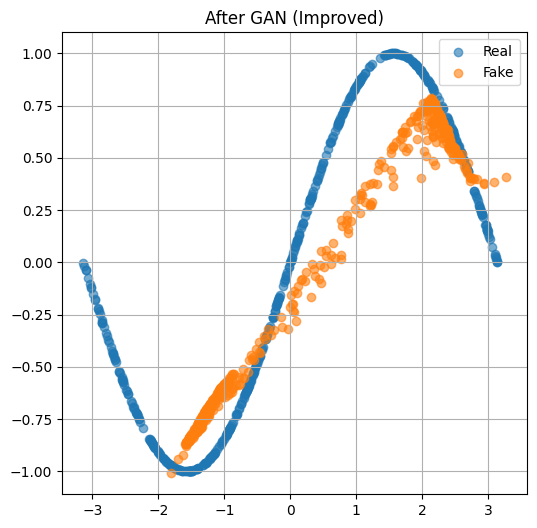

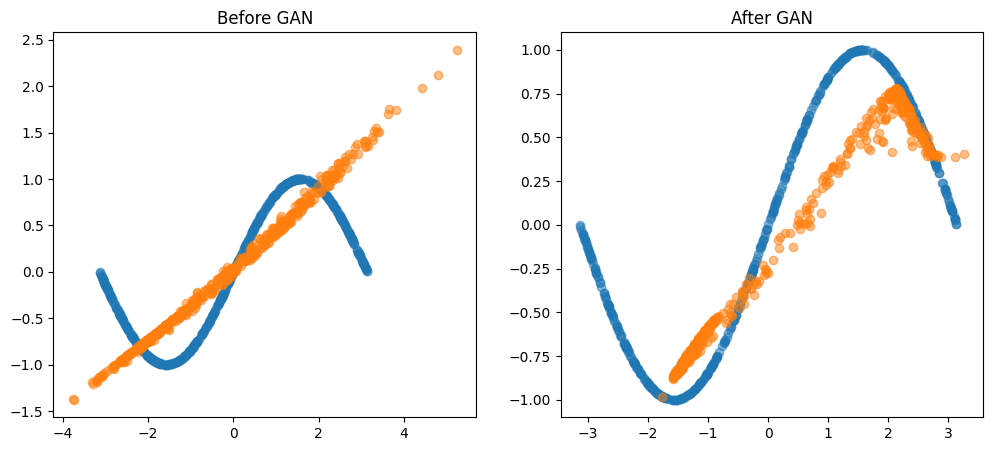

In [12]:
plot_data(gen_before, sample_sine, "Before GAN (Sine)")
plot_data(gen_after, sample_sine, "After GAN (Improved)")
compare_models(gen_before, gen_after, sample_sine)

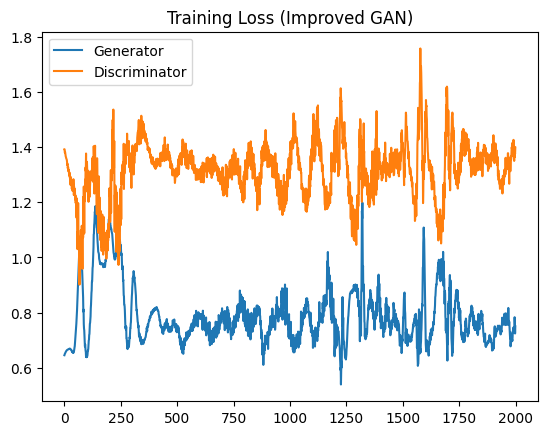

In [13]:
plt.plot(g_loss_a, label="Generator")
plt.plot(d_loss_a, label="Discriminator")
plt.legend()
plt.title("Training Loss (Improved GAN)")
plt.show()

/tmp/ipykernel_2204/220616880.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(data, dtype=torch.float32)


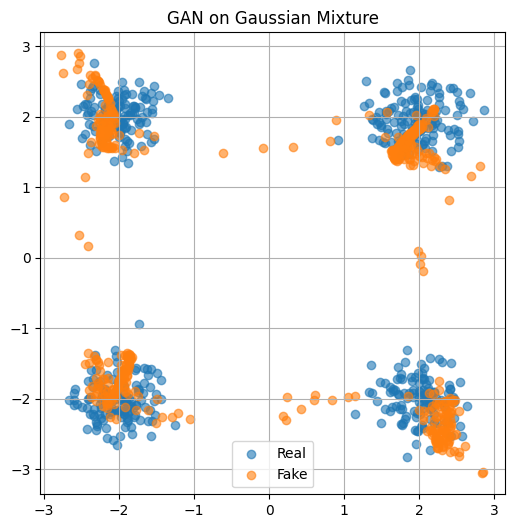

In [14]:
gen_gauss = GeneratorImproved()
disc_gauss = DiscriminatorImproved()

train_gan(gen_gauss, disc_gauss, sample_gaussians)

plot_data(gen_gauss, sample_gaussians, "GAN on Gaussian Mixture")

In [15]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.7 MB/s eta 0:00:00


In [16]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import medmnist
from medmnist import BloodMNIST
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [17]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = BloodMNIST(split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 35.5M/35.5M [00:29<00:00, 1.18MB/s]


In [18]:
def show_samples(dataset):
    fig, axes = plt.subplots(1, 6, figsize=(12,3))

    for i in range(6):
        img, label = dataset[i]

        img = img.numpy()
        img = np.transpose(img, (1, 2, 0))
        img = (img + 1) / 2

        axes[i].imshow(img)
        axes[i].set_title(f"Class {label.item()}")
        axes[i].axis('off')

    plt.show()

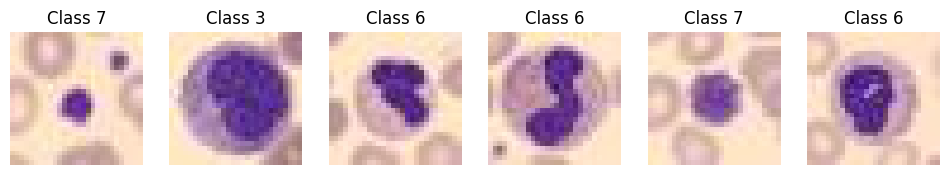

In [19]:
show_samples(train_dataset)

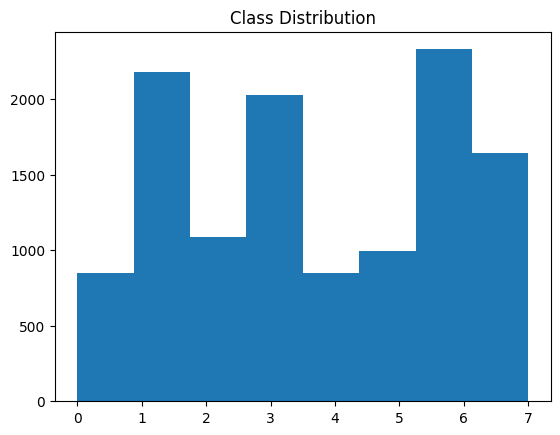

In [20]:
labels = [label.item() for _, label in train_dataset]
plt.hist(labels, bins=8)
plt.title("Class Distribution")
plt.show()

In [21]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(noise_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [22]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # FIXED KERNEL SIZE
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_opt = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

loss_fn = nn.BCELoss()

In [24]:
g_losses = []
d_losses = []

for epoch in range(10):
    for real_imgs, _ in train_loader:

        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)


        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_imgs = generator(z)

        d_real = discriminator(real_imgs)
        d_fake = discriminator(fake_imgs.detach())

        d_loss = loss_fn(d_real, real_labels) + loss_fn(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_imgs = generator(z)

        d_fake = discriminator(fake_imgs)
        g_loss = loss_fn(d_fake, real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch}: D Loss={d_loss.item():.4f}, G Loss={g_loss.item():.4f}")

Epoch 0: D Loss=0.7711, G Loss=2.8778
Epoch 1: D Loss=0.9696, G Loss=1.2387
Epoch 2: D Loss=0.4641, G Loss=1.9749
Epoch 3: D Loss=0.6003, G Loss=1.3023
Epoch 4: D Loss=0.4104, G Loss=2.6176
Epoch 5: D Loss=0.7481, G Loss=2.8861
Epoch 6: D Loss=0.2676, G Loss=2.2810
Epoch 7: D Loss=0.7824, G Loss=2.0593
Epoch 8: D Loss=0.2276, G Loss=3.4127
Epoch 9: D Loss=0.3789, G Loss=2.1301


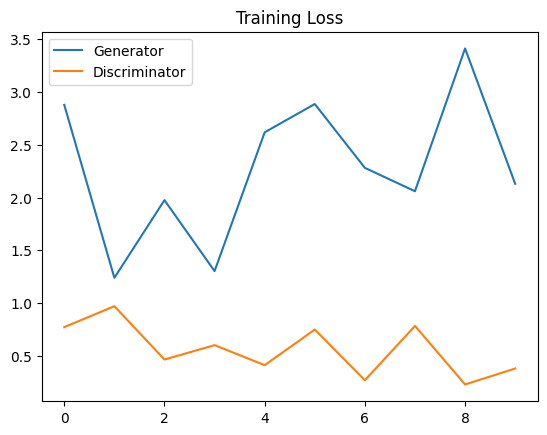

In [25]:
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

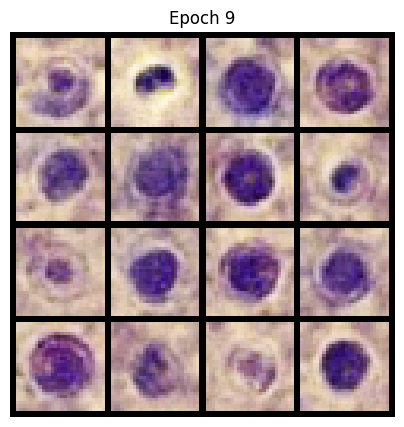

In [26]:
def generate_images(generator, epoch, n=16):
    z = torch.randn(n, 100, 1, 1).to(device)
    fake_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(fake_imgs, nrow=4, normalize=True)

    plt.figure(figsize=(5,5))
    plt.imshow(grid.permute(1,2,0))
    plt.axis('off')
    plt.title(f"Epoch {epoch}")

    plt.savefig(f"generated_epoch_{epoch}.png")
    plt.show()
generate_images(generator, epoch)

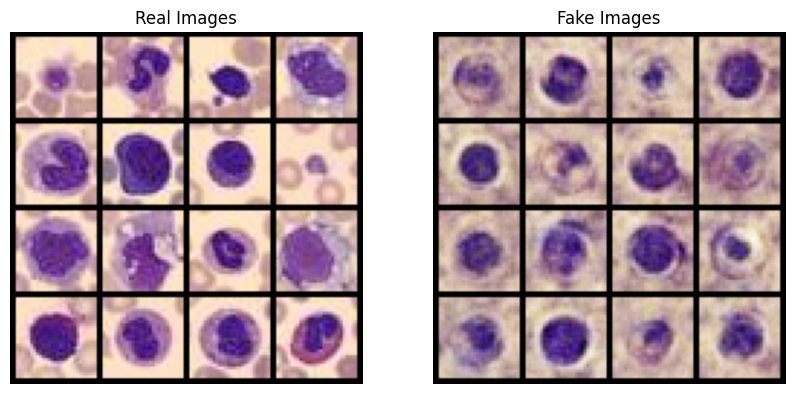

In [27]:

def compare_real_fake(loader, generator):
    real_imgs, _ = next(iter(loader))
    real_imgs = real_imgs[:16]

    z = torch.randn(16, 100, 1, 1).to(device)
    fake_imgs = generator(z).detach().cpu()

    real_grid = torchvision.utils.make_grid(real_imgs, nrow=4, normalize=True)
    fake_grid = torchvision.utils.make_grid(fake_imgs, nrow=4, normalize=True)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(real_grid.permute(1,2,0))
    plt.title("Real Images")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(fake_grid.permute(1,2,0))
    plt.title("Fake Images")
    plt.axis('off')

    plt.show()

compare_real_fake(train_loader, generator)

In [28]:
!pip install pytorch-fid

In [29]:
!pip install kaggle

In [30]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

In [31]:
!kaggle datasets download -d chethuhn/network-intrusion-dataset

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:02<00:00, 119MB/s]



In [32]:
!unzip -j network-intrusion-dataset.zip "*Wednesday*" -d data/

Archive:  network-intrusion-dataset.zip
  inflating: data/Wednesday-workingHours.pcap_ISCX.csv  


In [33]:
file_path = "data/Wednesday-workingHours.pcap_ISCX.csv"

chunks = []
for chunk in pd.read_csv(file_path, chunksize=50000):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

In [34]:
def reduce_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

df = reduce_memory(df)

In [35]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [36]:
df['Label'] = df[' Label'].map({'BENIGN': 0, 'DoS': 1})

In [37]:
X = df.drop('Label', axis=1)

non_numeric_cols = X.select_dtypes(exclude=['number']).columns
print(non_numeric_cols)

Index([' Label'], dtype='object')


In [38]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df.columns = df.columns.str.strip()

print("Columns:", df.columns)

y = df['Label']


X = df.drop(columns=['Label'])


X = X.apply(pd.to_numeric, errors='coerce')


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

y = y.loc[X.index]

print("Any object columns?", X.select_dtypes(exclude=['number']).columns)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Columns: Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SY

In [39]:
data_tensor = torch.tensor(X_scaled, dtype=torch.float32)
print(data_tensor.shape)

torch.Size([691406, 78])


In [40]:
from torch.utils.data import DataLoader, TensorDataset
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [41]:
class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, output_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [42]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [43]:
noise_dim = 50
input_dim = X_scaled.shape[1]

G = Generator(noise_dim, input_dim)
D = Discriminator(input_dim)

criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)

In [44]:
epochs = 15

g_losses = []
d_losses = []

for epoch in range(epochs):
    for real_data, in dataloader:

        batch_size = real_data.size(0)

        real_labels = torch.ones(batch_size, 1)
        fake_labels = torch.zeros(batch_size, 1)


        noise = torch.randn(batch_size, noise_dim)
        fake_data = G(noise)

        d_loss_real = criterion(D(real_data), real_labels)
        d_loss_fake = criterion(D(fake_data.detach()), fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        noise = torch.randn(batch_size, noise_dim)
        fake_data = G(noise)

        g_loss = criterion(D(fake_data), real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch+1}: D={d_loss.item():.4f}, G={g_loss.item():.4f}")

Epoch 1: D=0.5901, G=2.7605
Epoch 2: D=0.8243, G=2.0502
Epoch 3: D=0.4710, G=2.4798
Epoch 4: D=0.5175, G=1.7582
Epoch 5: D=0.6642, G=1.7427
Epoch 6: D=0.7370, G=2.0682
Epoch 7: D=0.4902, G=1.8021
Epoch 8: D=0.6516, G=2.3905
Epoch 9: D=1.7467, G=2.5955
Epoch 10: D=0.6435, G=2.3409
Epoch 11: D=0.6688, G=1.9001
Epoch 12: D=0.5621, G=2.1327
Epoch 13: D=0.7355, G=1.4363
Epoch 14: D=0.6815, G=2.2866
Epoch 15: D=0.6302, G=1.6838


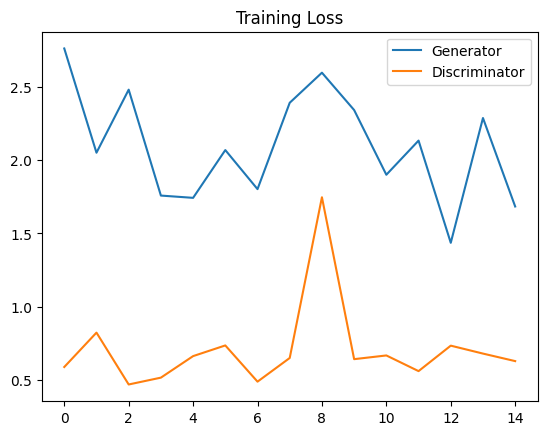

In [45]:
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

In [46]:
noise = torch.randn(1000, noise_dim)
fake_samples = G(noise).detach().numpy()

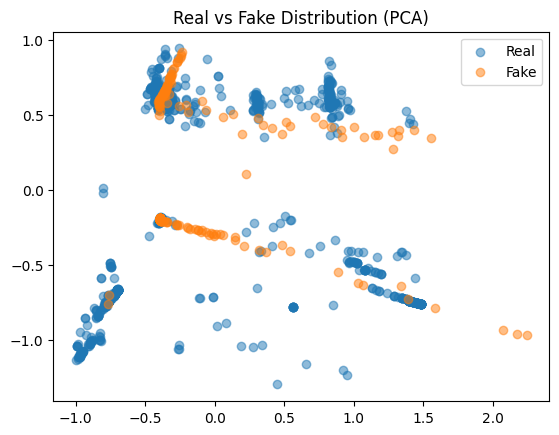

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

real_pca = pca.fit_transform(X_scaled[:1000])
fake_pca = pca.transform(fake_samples)

plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label="Real")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label="Fake")

plt.legend()
plt.title("Real vs Fake Distribution (PCA)")
plt.show()

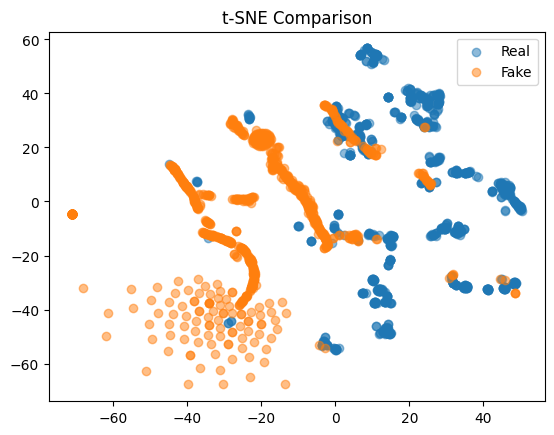

In [48]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)

combined = np.vstack([X_scaled[:1000], fake_samples])
tsne_result = tsne.fit_transform(combined)

plt.scatter(tsne_result[:1000, 0], tsne_result[:1000, 1], label="Real", alpha=0.5)
plt.scatter(tsne_result[1000:, 0], tsne_result[1000:, 1], label="Fake", alpha=0.5)

plt.legend()
plt.title("t-SNE Comparison")
plt.show()

In [49]:
!wget https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy

--2026-04-21 12:59:08--  https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.139.207, 74.125.141.207, 173.194.210.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.139.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102210944 (97M) [application/octet-stream]
Saving to: ‘pizza.npy’

pizza.npy           100%[===================>]  97.48M   138MB/s    in 0.7s    

2026-04-21 12:59:09 (138 MB/s) - ‘pizza.npy’ saved [102210944/102210944]



In [50]:
data = np.load("pizza.npy")

print(data.shape)

(130371, 784)


In [51]:
data = data / 255.0
data = (data - 0.5) * 2

data = data.reshape(-1, 1, 28, 28)

data = torch.tensor(data, dtype=torch.float32)

In [52]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(data)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [53]:
del generator

In [54]:
del discriminator

In [58]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [59]:
generator = Generator().to(device)

In [60]:
print(generator)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)


In [61]:
z = torch.randn(64, 100, 1, 1).to(device)
print(generator(z).shape)

torch.Size([64, 1, 28, 28])


In [66]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(

            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 3, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

In [67]:
discriminator = Discriminator().to(device)

In [68]:
print(real_imgs.shape)
print(fake_imgs.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])


In [69]:
g_losses, d_losses = [], []

for epoch in range(8):
    for (real_imgs,) in loader:

        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        z = torch.randn(batch_size, 100, 1, 1).to(device)

        with torch.no_grad():
            fake_imgs = generator(z)

        d_loss = loss_fn(discriminator(real_imgs), real_labels) + \
                 loss_fn(discriminator(fake_imgs), fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        z = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_imgs = generator(z)

        g_loss = loss_fn(discriminator(fake_imgs), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    torch.cuda.empty_cache()

    print(f"Epoch {epoch}: D={d_loss.item():.4f}, G={g_loss.item():.4f}")

Epoch 0: D=0.9538, G=0.7646
Epoch 1: D=1.2713, G=0.7604
Epoch 2: D=1.3092, G=0.7674
Epoch 3: D=1.3537, G=0.9179
Epoch 4: D=1.4024, G=0.8733
Epoch 5: D=1.0944, G=0.9214
Epoch 6: D=1.3075, G=0.8639
Epoch 7: D=1.0829, G=0.9042


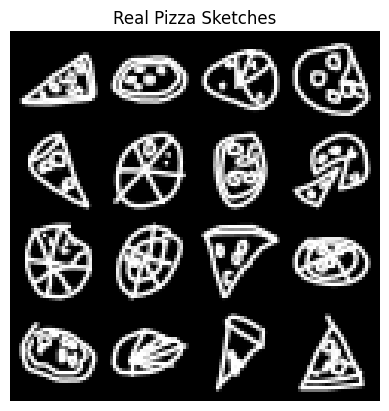

In [70]:
real_imgs = next(iter(loader))[0][:16]

real_grid = torchvision.utils.make_grid(real_imgs, nrow=4, normalize=True)

plt.imshow(real_grid.permute(1,2,0), cmap='gray')
plt.title("Real Pizza Sketches")
plt.axis('off')
plt.show()

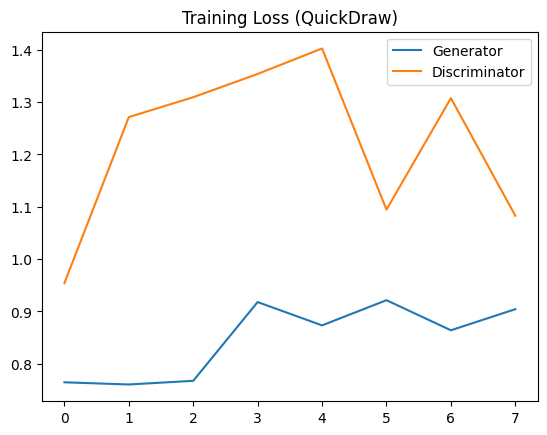

In [71]:
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.legend()
plt.title("Training Loss (QuickDraw)")
plt.show()

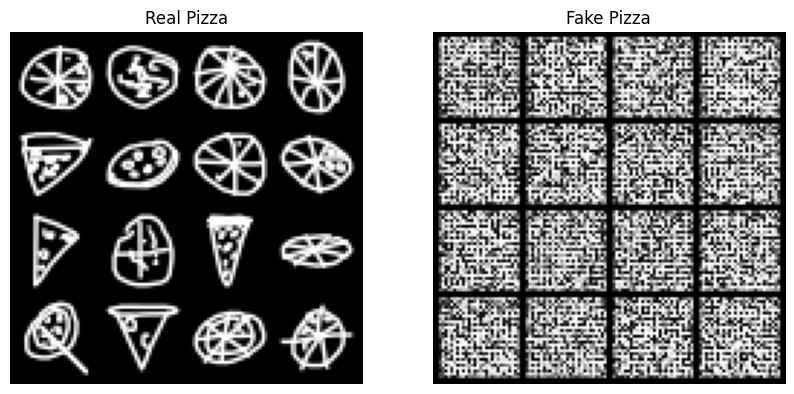

In [72]:
def compare_real_fake(loader, generator):
    real_imgs = next(iter(loader))[0][:16]

    z = torch.randn(16, 100, 1, 1).to(device)
    fake_imgs = generator(z).detach().cpu()

    real_grid = torchvision.utils.make_grid(real_imgs, nrow=4, normalize=True)
    fake_grid = torchvision.utils.make_grid(fake_imgs, nrow=4, normalize=True)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(real_grid.permute(1,2,0), cmap='gray')
    plt.title("Real Pizza")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(fake_grid.permute(1,2,0), cmap='gray')
    plt.title("Fake Pizza")
    plt.axis('off')

    plt.show()

compare_real_fake(loader, generator)